# CS 412 Machine Learning
## Spring 2026
## Homework 4

---

**Due:** April 27, 11:55 pm  
**Late Accepted Until:** April 29, 11:55 pm

### Student Information

In [12]:
NAME       = "Alp Eren Gül"     # e.g. "Emine Ayşe Sunar"
STUDENT_ID = "32452"        # e.g. "12345"

print(f"Student : {NAME}")
print(f"ID      : {STUDENT_ID}")

Student : Alp Eren Gül
ID      : 32452


## Instructions

- **Run all cells before submitting.** All outputs must be visible. The notebook will not be re-run during grading. Cells with no output will receive zero points.
- **Submission:** Upload your notebook as `CS412-HW4-FirstnameLastname.ipynb`.
- **Late policy:** Up to 2 days late accepted with a 10-point penalty per day. Submissions within the first hour after the deadline incur only a 5-point penalty.

---

## Overview

In this assignment, you will build and compare a **Multilayer Perceptron (MLP)** and a **Convolutional Neural Network (CNN)** for image classification on a 10-class subset of **Food-101**, a benchmark dataset of 101,000 food images across 101 categories (pizza, sushi, waffles, etc.), originally published at ECCV 2014. We work with 10 classes to keep training times manageable on Colab. The dataset is available on Sucourse as `Food10.zip`.

**Minimum test accuracy required:**
- MLP: **30%**
- CNN: **50%**

> ⚠️ **Important:** Reaching the minimum accuracy threshold is required. If your model does not meet the threshold, you will receive at most half of the points for that part, even if the rest of your implementation is correct.

---

## Grading

- **Part 1**: Numerical Questions: 20 pts
- **Part 2**: MLP Classifier: 25 pts
- **Part 3**: CNN Classifier: 40 pts
- **Part 4**: Comparison & Analysis: 15 pts
- **Total: 100 pts**

## Part 0: Setup and Data Loading

> 📌 **Note:** This section contains setup and data loading code. Run all cells in this section without modifying them.

Run the cell below to install and import all required libraries. Make sure you are using a GPU runtime on Colab (Runtime > Change runtime type > T4 GPU).

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 0.1 Data Loading

Download `Food10.zip` from Sucourse and upload it to your Google Drive **without renaming it**. Then run the cells below to mount your Drive and extract the dataset.

The dataset is a 10-class subset of [Food-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/) (Bossard et al., ECCV 2014). It contains 750 training and 250 test images per class across 10 food categories: pizza, sushi, waffles, ice cream, chocolate cake, hamburger, hot dog, ramen, donuts, and fried rice.

In [14]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [15]:
import os

zip_path  = "/content/drive/My Drive/Food10.zip"
target_dir = "/content/data"

if not os.path.exists(os.path.join(target_dir, "train")):
    print("Extracting dataset...")
    !unzip -q "{zip_path}" -d "/content/data"
    print("Extraction complete.")
else:
    print("Dataset already extracted, skipping.")

data_dir = target_dir
print("Using dataset at:", data_dir)

Dataset already extracted, skipping.
Using dataset at: /content/data


### 0.2 Preprocessing and Visualization

We resize all images to 64×64, apply normalization, and split the training data into train (80%) and validation (20%) sets.

In [16]:
IMG_SIZE = 64
SELECTED_CLASSES = [
    "pizza", "sushi", "waffles", "ice_cream", "chocolate_cake",
    "hamburger", "hot_dog", "ramen", "donuts", "fried_rice"
]

class FoodDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        self.transform = transform
        self.samples = []
        split_dir = os.path.join(root_dir, split)
        for label, class_name in enumerate(SELECTED_CLASSES):
            class_dir = os.path.join(split_dir, class_name)
            for fname in os.listdir(class_dir):
                if fname.endswith(".jpg"):
                    self.samples.append((os.path.join(class_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Compute mean and std from training set only
def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    for images, _ in loader:
        for c in range(3):
            mean[c] += images[:, c, :, :].mean()
            std[c] += images[:, c, :, :].std()
    mean /= len(loader)
    std /= len(loader)
    return mean, std

pre_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
temp_dataset = FoodDataset(data_dir, "train", transform=pre_transform)
mean, std = compute_mean_std(temp_dataset)
print(f"Mean: {mean}")
print(f"Std:  {std}")

# Define transforms using computed stats
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Create datasets and loaders
full_train_dataset = FoodDataset(data_dir, "train", transform=transform_train)
test_dataset       = FoodDataset(data_dir, "test",  transform=transform_eval)

val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Mean: tensor([0.5362, 0.4355, 0.3442])
Std:  tensor([0.2608, 0.2584, 0.2588])
Train: 6000 | Val: 1500 | Test: 2500


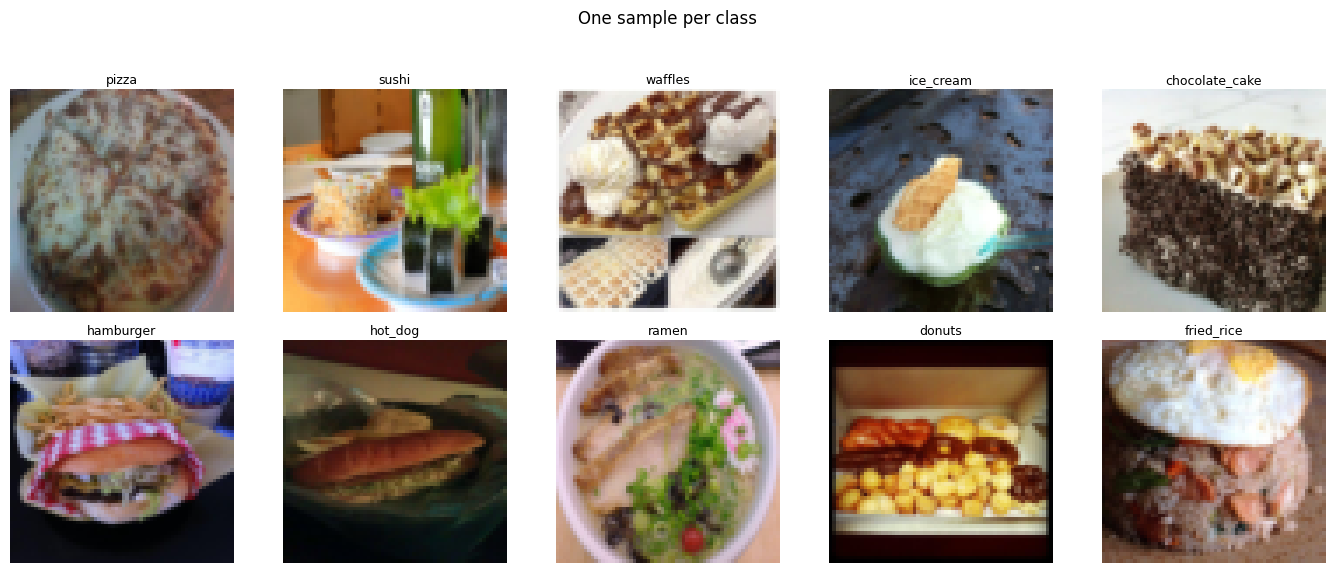

In [17]:
# Visualize one sample per class
display_dataset = FoodDataset(data_dir, "train", transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
]))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
shown = {}
idx = 0
while len(shown) < 10:
    img, label = display_dataset[idx]
    if label not in shown:
        shown[label] = img
    idx += 1

for ax, (label, img) in zip(axes.flatten(), sorted(shown.items())):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(SELECTED_CLASSES[label], fontsize=9, pad=4)
    ax.axis("off")

plt.suptitle("One sample per class", fontsize=12)
plt.tight_layout(pad=2.5)
plt.show()

## Part 1: Numerical Questions [20 pts]

> 📌 **Note:** The numerical questions in this section are independent of the Food-101 dataset. The input dimensions and configurations given here are hypothetical and are not related to the Food-101 dataset.

Answer the following questions in the answer cells provided. No code is needed for this part.

### Question 1.1 — Output Size [8 pts]

You have an input feature map of spatial size **40×40** with **3 channels**. You apply a convolutional layer with the following configuration:
- Filter size: 5×5
- Number of filters: 16
- Stride: 2
- Padding: 1

**(a)** What is the spatial size (height × width) of the output feature map? Show your calculation using the formula $W_{out} = \lfloor \frac{W + 2P - F}{S} \rfloor + 1$.

**(b)** What is the total number of learnable parameters in this layer, including biases?

**(c)** What would the output spatial size be if you instead used stride 1 and padding 2? Show your work. What is this special case of padding called, and what is its purpose?

**Your answer for 1.1:**

(a)
formula:
floor((W + 2P − F) / S) + 1  =>

W = 40
P = 1
F = 5
S = 2

calculation:
40 + 2×1 − 5 = 37
37 / 2 = 18.5
floor(18.5) = 18
18 + 1 = 19

output spatial size: spatial size = 19 × 19

output size: 19 × 19 × 16

(b)
each filter see 5 × 5 × 3 = 75 weight
and 1 parameter for each bias: 75 + 1 = 76 parameter

since 16 filters: 16 × 76 = 1216

Total learnable parameters = 1216

(c)
new values:
W = 40
P = 2
F = 5
S = 1

calculation:
40 + 2×2 − 5 = 39
39 / 1 = 39
39 + 1 = 40


Output spatial size = 40 × 40

This special case is called same padding. Its purpose is to preserve the spatial size of the input, so when stride is 1, the output height and width remain the same as the input height and width.

### Question 1.2 — Conceptual Questions [12 pts]

**(a)** What is **weight sharing** in a convolutional layer and why does it make CNNs more parameter-efficient than MLPs for image inputs?

**(b)** A CNN is said to be **translation equivariant**. What does this mean? Give a concrete example using the food images in this dataset.

**(c)** A max pooling layer with a 2×2 window and stride 2 is applied to a feature map of size 32×32×64. What is the output size? How many learnable parameters does this pooling layer have, and why?

**Your answer for 1.2:**

(a)
Weight sharing means that the same convolution filter is reused across different spatial locations of the input image. Instead of learning a separate set of weights for every pixel position, a CNN learns a small filter, such as a 3×3 or 5×5 filter, and slides it over the whole image. At each location, the filter checks whether a certain local pattern exists there.

This makes CNNs much more parameter-efficient than MLPs for image inputs. In an MLP, every input pixel is connected to many neurons with separate weights, so the number of parameters grows very quickly when the image size increases. For example, even a small image has thousands of pixel values, and a fully connected layer would need a separate weight for each connection. In a CNN, however, the same filter weights are reused everywhere, so the number of parameters depends mainly on the filter size and the number of filters, not directly on the full image width and height.

This is especially important for image classification because a feature, such as a pizza crust, sushi texture, or hamburger bun, can appear in different parts of an image. A CNN can detect this feature in different locations using the same filter.



(b)
Translation equivariance means that when a pattern in the input image shifts to a different location, the corresponding activation in the CNN’s feature map also shifts in the same way. In other words, the CNN does not lose the feature just because it moved. Instead, the location of the activation changes according to the new location of the feature.

For example, suppose a CNN has learned a filter that detects pepperoni on a pizza. If the pepperoni appears in the top-left part of the image, the filter will produce a strong activation in the top-left region of the feature map. If the same pepperoni appears in the bottom-right part of another image, the same filter can still detect it, but now the strong activation appears in the bottom-right region of the feature map.

So, the CNN does not completely forget the object; only the location of the feature changes.

(c)
Input:

32 × 32 × 64

Max pooling:

2 × 2 window
stride = 2

The spatial size is reduced by half:

32 / 2 = 16

Output:

16 × 16 × 64

The number of learnable parameters in the pooling layer is:

0

Because max pooling does not learn any weights. It only selects the maximum value from each 2 × 2 region.

## Part 2: MLP Classifier [25 pts]

In this part, you will implement and train a Multilayer Perceptron (MLP) to classify food images. For the MLP, images must be **flattened** into a 1D vector before being fed into the network.

**Requirement:** Your MLP must achieve at least **30% top-1 accuracy** on the test set.

### 2.1 Model Implementation [10 pts]

Implement your MLP by completing the class below. You are free to choose the number of layers and neurons, but your network must satisfy the following:
- At least 2 hidden layers
- ReLU activations
- At least one Dropout layer

The input dimension is 64×64×3 = 12,288.

In [18]:
class MLP(nn.Module):
    def __init__(self, input_dim=64*64*3, num_classes=10):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = self.network(x)
        return x

mlp_model = MLP().to(device)
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total trainable parameters: 13,246,218


### 2.2 Training [10 pts]

Train your MLP using the training set and evaluate on the validation set each epoch. You must:
- Use `CrossEntropyLoss`
- Train for at least 15 epochs
- Print training loss and validation accuracy per epoch
- Plot training loss and validation accuracy curves

In [19]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, dim=1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}  Val Acc: {val_acc:.2f}%")

    return train_losses, val_accuracies

mlp_train_losses, mlp_val_accs = train_model(mlp_model, train_loader, val_loader, num_epochs=20)

Epoch [1/20]  Loss: 2.1626  Val Acc: 26.60%
Epoch [2/20]  Loss: 2.0212  Val Acc: 31.13%
Epoch [3/20]  Loss: 1.9428  Val Acc: 31.60%
Epoch [4/20]  Loss: 1.8682  Val Acc: 33.00%
Epoch [5/20]  Loss: 1.8178  Val Acc: 33.53%
Epoch [6/20]  Loss: 1.7558  Val Acc: 31.07%
Epoch [7/20]  Loss: 1.7027  Val Acc: 31.13%
Epoch [8/20]  Loss: 1.6443  Val Acc: 33.67%
Epoch [9/20]  Loss: 1.6089  Val Acc: 32.40%
Epoch [10/20]  Loss: 1.5656  Val Acc: 31.20%
Epoch [11/20]  Loss: 1.5003  Val Acc: 32.47%
Epoch [12/20]  Loss: 1.4480  Val Acc: 33.60%
Epoch [13/20]  Loss: 1.4071  Val Acc: 31.20%
Epoch [14/20]  Loss: 1.3645  Val Acc: 30.73%
Epoch [15/20]  Loss: 1.3338  Val Acc: 31.27%
Epoch [16/20]  Loss: 1.2822  Val Acc: 31.40%
Epoch [17/20]  Loss: 1.2485  Val Acc: 32.00%
Epoch [18/20]  Loss: 1.2082  Val Acc: 30.33%
Epoch [19/20]  Loss: 1.1644  Val Acc: 30.73%
Epoch [20/20]  Loss: 1.1193  Val Acc: 30.60%


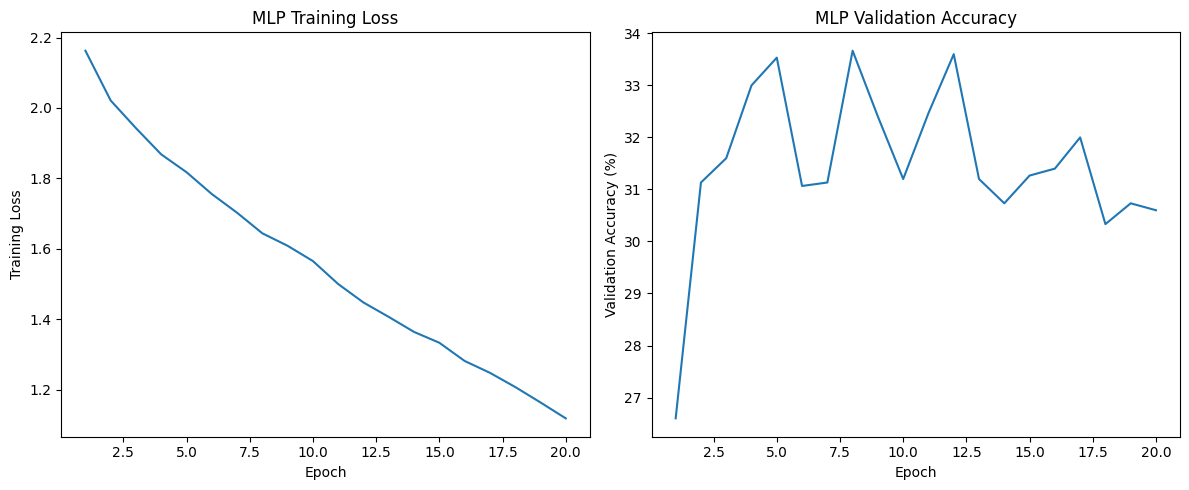

In [20]:
epochs = range(1, len(mlp_train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, mlp_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, mlp_val_accs)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("MLP Validation Accuracy")

plt.tight_layout()
plt.show()

### 2.3 Test Evaluation [5 pts]

Evaluate your trained MLP on the test set. You must meet the 30% threshold to receive full marks.

In [21]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return acc, all_preds, all_labels

mlp_test_acc, mlp_preds, mlp_labels = evaluate(mlp_model, test_loader)
print(f"MLP Test Accuracy: {mlp_test_acc:.2f}%")
assert mlp_test_acc >= 30.0, f"Accuracy {mlp_test_acc:.2f}% is below the required 30% threshold!"
print("Threshold requirement met.")

MLP Test Accuracy: 31.68%
Threshold requirement met.


## Part 3: CNN Classifier [40 pts]

Now you will implement a CNN. Unlike the MLP, the CNN operates directly on the 2D spatial structure of the image, so do not flatten the input at the beginning.

**Requirement:** Your CNN must achieve at least **50% top-1 accuracy** on the test set.

### 3.1 Model Implementation [15 pts]

Implement your CNN by completing the class below. Your network must satisfy the following:
- At least 3 convolutional layers
- ReLU activations after each conv layer
- At least one max pooling layer
- At least one Dropout layer in the classifier head
- The final layer must output logits for 10 classes

> 💡 **Tip:** If you are struggling to meet the accuracy threshold, consider adding `nn.BatchNorm2d` after your convolutional layers. Batch normalization stabilizes training and often leads to faster convergence and better performance.

In [22]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

cnn_model = CNN().to(device)
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

### 3.2 Training [15 pts]

Train your CNN using the same `train_model` function from Part 2. Plot the training curves.

In [23]:
cnn_train_losses, cnn_val_accs = train_model(
    cnn_model,
    train_loader,
    val_loader,
    num_epochs=25,
    lr=1e-3
)

Epoch [1/25]  Loss: 2.2717  Val Acc: 31.80%
Epoch [2/25]  Loss: 1.9691  Val Acc: 28.73%
Epoch [3/25]  Loss: 1.8679  Val Acc: 39.60%
Epoch [4/25]  Loss: 1.7775  Val Acc: 39.93%
Epoch [5/25]  Loss: 1.6910  Val Acc: 44.27%
Epoch [6/25]  Loss: 1.6228  Val Acc: 44.47%
Epoch [7/25]  Loss: 1.5548  Val Acc: 48.20%
Epoch [8/25]  Loss: 1.4978  Val Acc: 46.20%
Epoch [9/25]  Loss: 1.4436  Val Acc: 49.93%
Epoch [10/25]  Loss: 1.3683  Val Acc: 51.27%
Epoch [11/25]  Loss: 1.3424  Val Acc: 53.20%
Epoch [12/25]  Loss: 1.2943  Val Acc: 51.73%
Epoch [13/25]  Loss: 1.2817  Val Acc: 55.27%
Epoch [14/25]  Loss: 1.1844  Val Acc: 55.87%
Epoch [15/25]  Loss: 1.1610  Val Acc: 55.80%
Epoch [16/25]  Loss: 1.1416  Val Acc: 58.80%
Epoch [17/25]  Loss: 1.0694  Val Acc: 55.07%
Epoch [18/25]  Loss: 1.0415  Val Acc: 55.87%
Epoch [19/25]  Loss: 1.0090  Val Acc: 56.27%
Epoch [20/25]  Loss: 0.9935  Val Acc: 55.27%
Epoch [21/25]  Loss: 0.9534  Val Acc: 56.07%
Epoch [22/25]  Loss: 0.9185  Val Acc: 57.07%
Epoch [23/25]  Loss

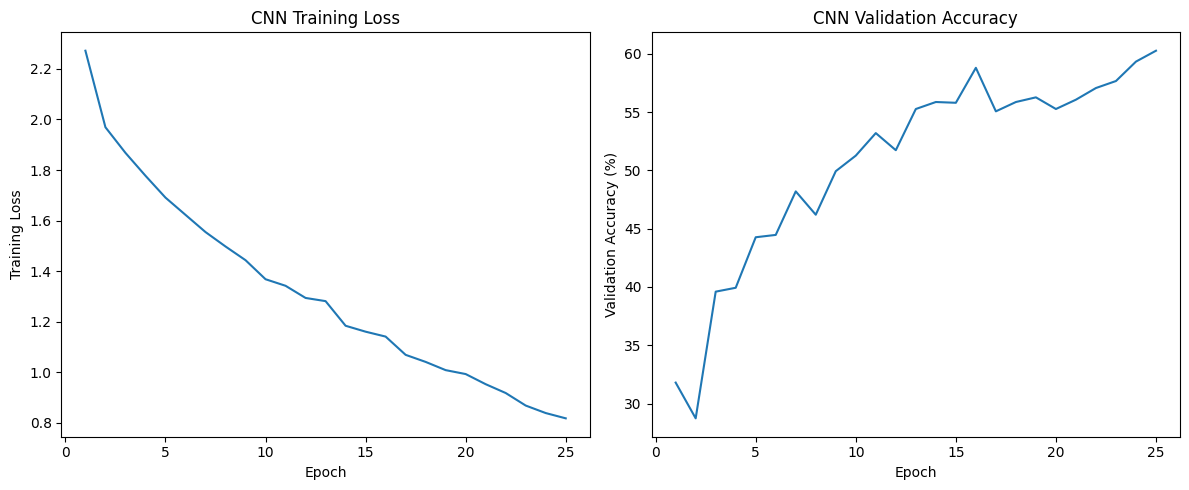

In [24]:
epochs = range(1, len(cnn_train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_val_accs)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("CNN Validation Accuracy")

plt.tight_layout()
plt.show()

### 3.3 Test Evaluation [10 pts]

Evaluate your trained CNN on the test set. You must meet the 50% threshold to receive full marks.

In [25]:
cnn_test_acc, cnn_preds, cnn_labels = evaluate(cnn_model, test_loader)

In [26]:
print(f"CNN Test Accuracy: {cnn_test_acc:.2f}%")
assert cnn_test_acc >= 50.0, f"Accuracy {cnn_test_acc:.2f}% is below the required 50% threshold!"
print("Threshold requirement met.")

CNN Test Accuracy: 62.44%
Threshold requirement met.


## Part 4: Comparison and Analysis [15 pts]

### 4.1 Side-by-Side Validation Accuracy Comparison [5 pts]

Plot both models' validation accuracy on the same graph.

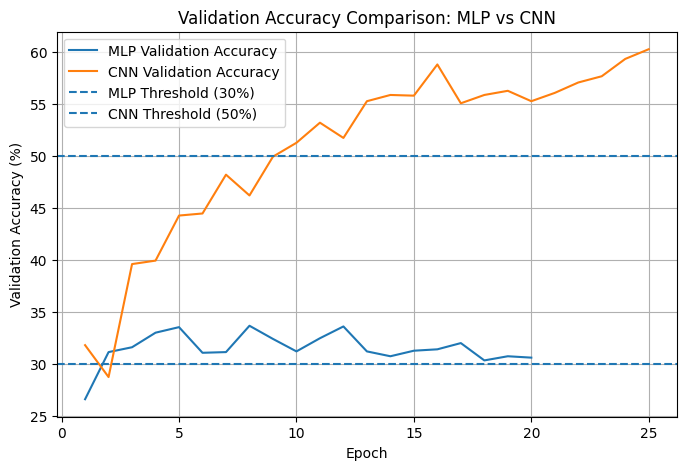

Final MLP Test Accuracy: 31.68%
Final CNN Test Accuracy: 62.44%


In [27]:
mlp_epochs = range(1, len(mlp_val_accs) + 1)
cnn_epochs = range(1, len(cnn_val_accs) + 1)

plt.figure(figsize=(8, 5))

plt.plot(mlp_epochs, mlp_val_accs, label="MLP Validation Accuracy")
plt.plot(cnn_epochs, cnn_val_accs, label="CNN Validation Accuracy")

plt.axhline(y=30, linestyle="--", label="MLP Threshold (30%)")
plt.axhline(y=50, linestyle="--", label="CNN Threshold (50%)")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison: MLP vs CNN")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final MLP Test Accuracy: {mlp_test_acc:.2f}%")
print(f"Final CNN Test Accuracy: {cnn_test_acc:.2f}%")

### 4.2 Discussion [10 pts]

**(a)** If correctly implemented, the CNN should significantly outperform the MLP on this task. Explain why this is expected using the concepts of **locality** and **weight sharing**. Why are these properties particularly useful for food image classification?

**(b)** Look at your training curves for both models. Which model shows signs of overfitting, underfitting, or neither? Suggest one concrete change you could make to improve the weaker model and explain why it would help.

**Your answer for 4.2:**

(a)The CNN significantly outperforms the MLP because CNNs are designed to work better with image data. The MLP first flattens the image into a one-dimensional vector, so it loses the spatial relationship between nearby pixels. Because of this, the MLP has difficulty learning local visual patterns such as edges, corners, textures, toppings, bread shapes, or sushi patterns.

The CNN uses locality because each convolution filter looks at a small local region of the image instead of looking at the whole flattened image at once. This helps the model learn useful local features, such as pizza crusts, hamburger buns, cheese texture, rice texture, or sauce patterns. CNNs also use weight sharing, meaning the same filter is reused across different locations of the image. This is important because the same food feature can appear in different positions. For example, pepperoni on a pizza or the texture of sushi can appear near the center, corner, top, or bottom of the image. The CNN can detect the same feature using the same filter wherever it appears.

These properties are especially useful for food image classification because food categories are often recognized by local textures, shapes, colors, and repeated visual patterns. In my results, the MLP reached a best validation accuracy of 33.67%, while the CNN reached a final validation accuracy of 60.27%. This shows that the CNN learned more useful image features than the MLP.

(b)

Based on the training curves, the MLP shows signs of underfitting and weak generalization. Its training loss decreases from 2.1626 to 1.1193, which means the model is learning from the training data. However, its validation accuracy stays around 30–33% and does not improve consistently after the early epochs. The best validation accuracy of the MLP is only 33.67%. This suggests that the MLP is not able to learn strong visual features from the images because it loses spatial structure after flattening the input.

The CNN performs much better. Its training loss decreases from 2.2717 to 0.8184, and its validation accuracy increases from 31.80% to 60.27%. This shows that the CNN is learning useful patterns from the data and generalizing better than the MLP. There are small fluctuations in the CNN validation accuracy, for example around epochs 16–23, but the overall trend still improves, and the final validation accuracy is the highest. Therefore, the CNN does not show serious overfitting in this result.

One concrete change to improve the weaker model, the MLP, would be to replace it with a convolutional architecture or add convolutional layers before the fully connected layers. This would help because convolutional layers preserve local spatial information and can detect visual patterns such as edges, textures, and shapes. If the model must remain an MLP, data augmentation or stronger regularization could help slightly, but the main weakness is architectural. The MLP is weaker mainly because it flattens the image and cannot use locality and weight sharing like the CNN.
